**Homework 02: Student Performance Predictoin**

**1. Environment Setup**

In [236]:
%pip install pandas numpy

In [237]:
import pandas as pd
import numpy as np

In [238]:
%pip install seaborn matplotlib

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt

**2. Data Preparation**

In [241]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML Course/HW 02/student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [243]:
#Change column name to all lower case
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   pstatus     649 non-null    object
 6   medu        649 non-null    int64 
 7   fedu        649 non-null    int64 
 8   mjob        649 non-null    object
 9   fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [244]:
df.loc[100]

,100
school,GP
sex,M
age,16
address,U
famsize,GT3
pstatus,T
medu,4
fedu,4
mjob,services
fjob,services


In [245]:
df[100:105]

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
100,GP,M,16,U,GT3,T,4,4,services,services,...,4,5,5,5,5,4,12,9,9,8
101,GP,M,16,U,GT3,T,4,4,services,teacher,...,4,4,3,1,1,4,0,16,16,16
102,GP,M,15,U,GT3,T,4,4,services,other,...,5,3,3,1,1,5,2,12,13,12
103,GP,F,15,U,GT3,T,3,2,services,other,...,4,3,5,1,1,2,16,11,10,10
104,GP,M,15,U,GT3,A,3,4,services,other,...,5,4,4,1,1,1,0,16,16,16


In [246]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
pstatus,0
medu,0
fedu,0
mjob,0
fjob,0


**3. EDA**

In [247]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5]) # display value of unique column
    print(df[col].nunique()) # display number of unique column

school
['GP' 'MS']
2
sex
['F' 'M']
2
age
[18 17 15 16 19]
8
address
['U' 'R']
2
famsize
['GT3' 'LE3']
2
pstatus
['A' 'T']
2
medu
[4 1 3 2 0]
5
fedu
[4 1 2 3 0]
5
mjob
['at_home' 'health' 'other' 'services' 'teacher']
5
fjob
['teacher' 'other' 'services' 'health' 'at_home']
5
reason
['course' 'other' 'home' 'reputation']
4
guardian
['mother' 'father' 'other']
3
traveltime
[2 1 3 4]
4
studytime
[2 3 1 4]
4
failures
[0 3 1 2]
4
schoolsup
['yes' 'no']
2
famsup
['no' 'yes']
2
paid
['no' 'yes']
2
activities
['no' 'yes']
2
nursery
['yes' 'no']
2
higher
['yes' 'no']
2
internet
['no' 'yes']
2
romantic
['no' 'yes']
2
famrel
[4 5 3 1 2]
5
freetime
[3 2 4 1 5]
5
goout
[4 3 2 1 5]
5
dalc
[1 2 5 3 4]
5
walc
[1 3 2 4 5]
5
health
[3 5 1 2 4]
5
absences
[ 4  2  6  0 10]
24
g1
[ 0  9 12 14 11]
17
g2
[11 13 14 12 16]
16
g3
[11 12 14 13 17]
17


<Axes: xlabel='g1', ylabel='Count'>

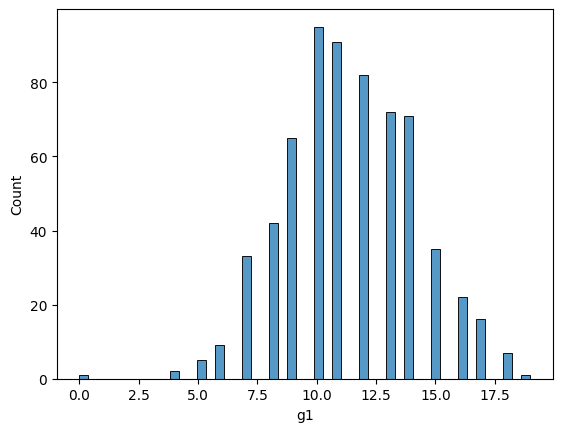

In [248]:
sns.histplot(df.g1, bins=50)

<Axes: xlabel='g2', ylabel='Count'>

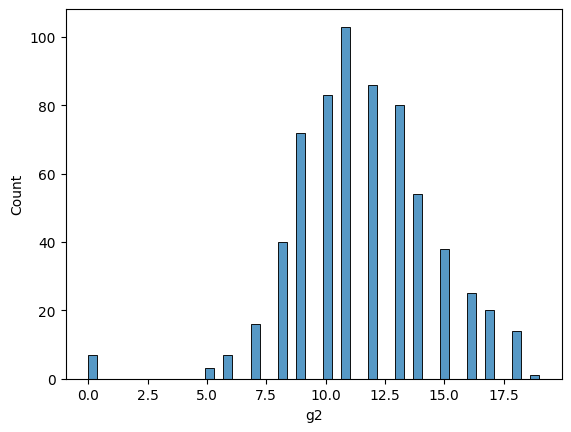

In [249]:
sns.histplot(df.g2, bins=50)

<Axes: xlabel='g3', ylabel='Count'>

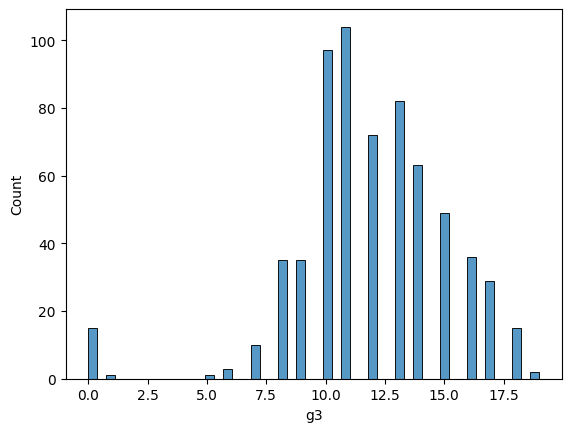

In [250]:
sns.histplot(df.g3, bins=50)

<Axes: xlabel='g3', ylabel='Count'>

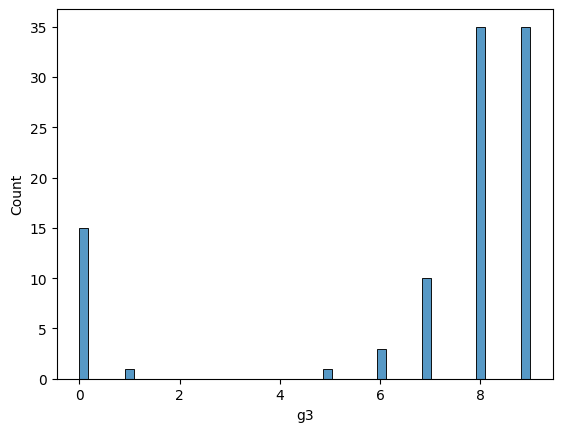

In [251]:
sns.histplot(df.g3[df.g3 < 10], bins=50)

In [252]:
grade3_log = np.log1p(df.g3)
grade3_log

,g3
0,2.484907
1,2.484907
2,2.564949
3,2.708050
4,2.639057
...,...
644,2.397895
645,2.833213
646,2.302585
647,2.397895


<Axes: xlabel='g3', ylabel='Count'>

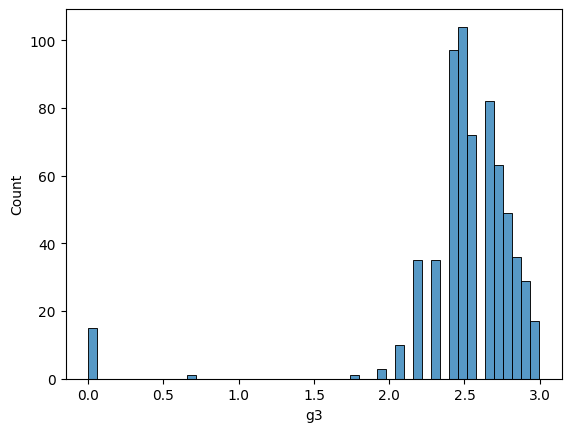

In [253]:
sns.histplot(grade3_log, bins=50)

**4. Validation Framework**

In [254]:
# total records
len(df)

649

In [255]:
#Split into 3 datasets
n = len(df)
n_val = n_test = int(n*0.2)
n_train = n - n_val - n_test

n, n_train, n_val, n_test

(649, 391, 129, 129)

In [256]:
#To random index in dataset
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([530, 498, 503, 106, 157, 396, 434, 356, 466, 493, 183, 430, 448,
       569, 142, 517,  14,  82,  12, 263, 147, 295, 549, 522, 340,  60,
       591, 529, 148, 253, 604,  93, 193, 432, 179,  25, 244, 510,  27,
       413, 310,  74, 296, 151, 375, 611, 566, 349,  88, 526, 420, 523,
       140, 519, 444, 118, 119, 499, 388, 314, 320, 561, 620, 158, 397,
       610, 473, 260,  17, 384, 213, 254, 206, 264, 348,  67, 541, 135,
       165, 343, 186, 402, 575, 109, 474, 587, 505, 560, 336, 251, 144,
       297, 313, 641,  44, 161, 407, 406,  91, 624,  77,  32, 602, 228,
        54, 382, 574, 146, 433, 126, 416, 289, 477, 527, 368,  16,  66,
        99, 321,  71, 484, 272, 379, 222,  62, 424, 369, 209, 557, 334,
       634, 607, 294, 616, 378, 403,  89, 445, 107, 595, 283, 537, 578,
       298, 355, 567, 269, 442, 178, 225, 218, 243, 238,  46, 548, 265,
       491, 133, 457, 507, 552,  28, 199, 571,  43, 274, 280, 425, 102,
       286,   9, 632, 202,  33, 169,  95,  55, 174, 534, 421, 25

In [257]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_val:n_val + n_test]]

In [258]:
#Reset index to start from 0 or 1
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [259]:
y_train = np.log1p(df_train.g3.values)
y_val = np.log1p(df_val.g3.values)
y_test = np.log1p(df_test.g3.values)

In [260]:
df_train_bk = df_train.copy()
df_val_bk = df_val.copy()
df_test_bk = df_test.copy()

In [262]:
#Delete field g3 from dataset
del df_train['g3']
del df_val['g3']
del df_test['g3']

**5. Linear Regrestion**

In [263]:
def train_linear_regression(X, Y):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones,X])

  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(Y)
  return w_full[0], w_full[1:]

In [264]:
base_column = [
    'age',
    'medu',
    'fedu',
    'traveltime',
    'studytime',
    'failures',
    'famrel',
    'freetime',
    'goout',
    'dalc',
    'walc',
    'health',
    'absences',
    'g1',
    'g2'
]

In [265]:
X_train = df_train[base_column].values
X_train

array([[17,  3,  3, ...,  8,  7, 10],
       [16,  2,  1, ...,  0, 14, 13],
       [16,  1,  1, ...,  0, 14, 14],
       ...,
       [17,  4,  3, ...,  0,  6,  9],
       [17,  2,  3, ...,  2,  9, 12],
       [18,  2,  2, ...,  0, 10,  9]])

In [266]:
X_train = df_train[base_column].fillna(0).values
X_train

array([[17,  3,  3, ...,  8,  7, 10],
       [16,  2,  1, ...,  0, 14, 13],
       [16,  1,  1, ...,  0, 14, 14],
       ...,
       [17,  4,  3, ...,  0,  6,  9],
       [17,  2,  3, ...,  2,  9, 12],
       [18,  2,  2, ...,  0, 10,  9]])

In [267]:
w0, w = train_linear_regression (X_train, y_train)
w0, w

(np.float64(1.878778502421636),
 array([-0.0346619 , -0.04599646,  0.03579117,  0.00273972,  0.02610168,
        -0.03869049, -0.00526873, -0.00876343,  0.01374081, -0.00923558,
        -0.00322787,  0.00521938,  0.00998138, -0.03684269,  0.13592582]))

In [268]:
y_pred = w0 + X_train.dot(w)
y_pred

array([2.44742801, 2.55551192, 2.80760306, 2.47191197, 2.27320448,
       2.96123605, 2.29219591, 2.93215009, 2.15298617, 2.29017653,
       2.89818783, 2.55630317, 3.00966375, 2.2409932 , 2.27478711,
       2.76411739, 2.7724323 , 2.45285142, 2.67282862, 2.05723332,
       2.82725467, 2.55935634, 3.04694394, 2.17846552, 2.80311294,
       2.8888923 , 2.65111752, 2.43136488, 2.28412795, 2.49257651,
       2.28012829, 2.69478115, 2.39302421, 1.85870656, 1.85574677,
       2.53112813, 2.39102541, 3.05250068, 2.36593807, 2.31509057,
       2.32601852, 2.46692682, 2.87517747, 2.57457329, 2.81346687,
       2.73886209, 1.86393965, 3.10777868, 2.31304227, 2.61718711,
       3.21397489, 1.93481683, 2.23201331, 1.95025405, 2.48563525,
       2.580489  , 2.65961626, 2.92161423, 2.49654312, 3.05942465,
       2.38335689, 2.21494272, 2.70478628, 2.40715263, 2.74323707,
       0.83527928, 2.04682674, 2.49808841, 2.78122584, 2.14012476,
       2.25485508, 2.14097113, 2.63110401, 2.15284837, 2.84328

<Axes: ylabel='Count'>

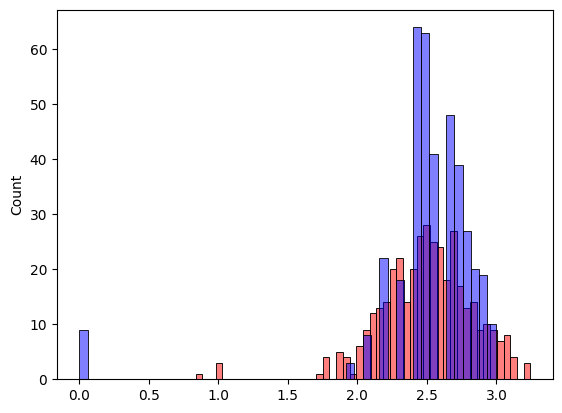

In [269]:
sns.histplot(y_pred, color = 'red', alpha = 0.5, bins =50)
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 50)

**6. Root Mean Squared Error (RSME)**

In [270]:
def rmse(y, y_pred):
  se = (y - y_pred) **2
  mse = se.mean()
  return np.sqrt(mse)

In [271]:
rmse(y_train, y_pred)

np.float64(0.27624952334604913)

In [272]:
#Use df_val to validate error
X_val = df_val[base_column].fillna(0).values
Y_val_pred = w0 + X_val.dot(w)
rmse(y_val, Y_val_pred)

np.float64(0.33772136954301235)

In [273]:
#Use df_val to validate error
X_test = df_test[base_column].fillna(0).values
Y_test_pred = w0 + X_test.dot(w)
rmse(y_test,Y_test_pred)

np.float64(0.24454629853557536)

In [274]:
np.expm1(y_pred)

array([10.55857993, 11.87789039, 15.57015294, 10.84507263,  8.71046798,
       18.32183972,  8.89664595, 17.76793996,  7.6105326 ,  8.87668107,
       17.14124063, 11.88808408, 19.28057948,  8.40266535,  8.72584824,
       14.86503113, 14.99749743, 10.62143715, 13.48087217,  6.82429252,
       15.89900375, 11.92749372, 20.05091324,  7.83274219, 15.49591775,
       16.97338952, 13.16986489, 10.37439614,  8.81712142, 11.0923922 ,
        8.77793476, 13.80227899,  9.94654855,  5.41543342,  5.39647317,
       11.56767609,  9.92469052, 20.16821319,  9.65402837,  9.12583995,
        9.23710148, 10.78617011, 16.7285701 , 12.12571506, 15.6676025 ,
       14.46937225,  5.44909394, 21.37129539,  9.10512044, 12.69714077,
       23.87777629,  5.92277589,  8.31860848,  6.03047346, 11.00874635,
       12.20359318, 13.29080405, 17.57124157, 11.14045327, 20.31528986,
        9.84123473,  8.16088437, 13.95112096, 10.10230373, 14.53719877,
        1.30545783,  6.74329062, 11.15922832, 15.13879234,  7.50

In [275]:
result_df_y_pred = pd.DataFrame(np.expm1(y_pred), columns = ['predic_g3'])
result_df_y_pred

,predic_g3
0,10.558580
1,11.877890
2,15.570153
3,10.845073
4,8.710468
...,...
386,11.770259
387,13.424306
388,8.491829
389,12.979092


In [278]:
#Show data and prediction result

dfmerge = df_train_bk
dfmerge['prediction_g3']=result_df_y_pred['predic_g3'].values.round(2)
dfmerge

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,freetime,goout,dalc,walc,health,absences,g1,g2,g3,prediction_g3
0,MS,M,17,U,GT3,T,3,3,services,services,...,1,4,5,5,3,8,7,10,9,10.56
1,MS,F,16,U,GT3,T,2,1,other,services,...,3,3,1,1,1,0,14,13,14,11.88
2,MS,F,16,U,GT3,T,1,1,other,other,...,2,1,1,1,5,0,14,14,14,15.57
3,GP,F,15,U,GT3,T,2,2,other,other,...,1,2,1,1,3,4,10,10,10,10.85
4,GP,F,15,U,LE3,A,2,1,at_home,other,...,4,2,1,1,5,0,11,10,10,8.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,GP,F,15,U,GT3,T,4,4,services,teacher,...,4,4,1,1,3,2,13,12,12,11.77
387,GP,F,16,U,GT3,T,4,4,other,other,...,3,4,1,2,1,4,12,13,13,13.42
388,MS,F,17,U,GT3,T,4,3,teacher,other,...,5,4,1,1,1,0,6,9,11,8.49
389,GP,M,17,U,GT3,T,2,3,other,other,...,2,2,1,1,2,2,9,12,13,12.98
